# Solar Energy Forecasting — Nairobi (NASA POWER)

**Business question.** Can we forecast daily surface solar irradiance in Nairobi 30 days ahead so utilities, off-grid solar operators, and grid integrators can plan dispatch, battery sizing, and generation forecasts?

Kenya has one of Africa's largest pay-as-you-go solar markets — 1-day-ahead irradiance errors flip whether a battery should be filled or left to discharge.

**Pipeline:** business question → data & EDA → modeling (SARIMA, state-space, GBM with weather covariates) → validation → deployment → outcome.

**Data:** [NASA POWER API](https://power.larc.nasa.gov/) — 10 years (2014–2023) of daily irradiance and weather for Nairobi. Free, no auth, fully programmatic.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.deterministic import Fourier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)
sns.set_style('whitegrid')

## 2. Load real NASA POWER data

In [2]:
df = pd.read_csv('data/nairobi_daily.csv', skiprows=14)
df['date'] = pd.to_datetime(df[['YEAR', 'MO', 'DY']].rename(columns={'YEAR':'year','MO':'month','DY':'day'}))
df = df.set_index('date').drop(columns=['YEAR','MO','DY']).sort_index().asfreq('D')
# NASA POWER uses -999 for missing — replace and interpolate
df = df.replace(-999, np.nan).interpolate(method='time')
print(f'period: {df.index.min().date()} → {df.index.max().date()}, n={len(df)}, NaNs left: {df.isna().sum().sum()}')
df.head()

period: 2014-01-01 → 2023-12-31, n=3652, NaNs left: 0


,ALLSKY_SFC_SW_DWN,T2M,RH2M,WS2M,PRECTOTCORR,CLOUD_AMT
date,,,,,,
2014-01-01,6.5520,19.88,70.67,3.18,0.31,70.08
2014-01-02,6.5878,19.56,69.38,3.89,0.45,70.87
2014-01-03,7.4160,19.46,68.85,3.55,0.01,7.93
2014-01-04,7.3034,19.43,67.18,3.33,0.05,11.33
2014-01-05,7.5300,19.29,59.05,3.56,0.02,3.38


## 3. EDA

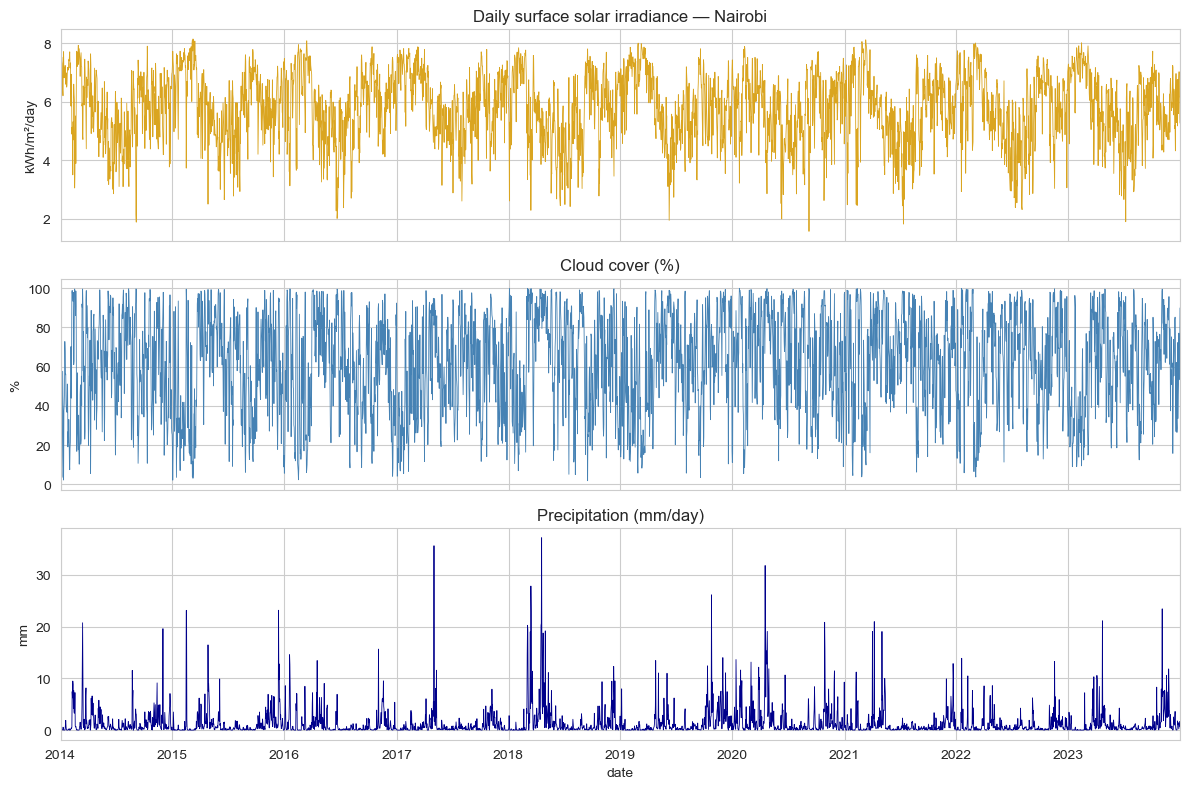

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
df['ALLSKY_SFC_SW_DWN'].plot(ax=axes[0], color='goldenrod', lw=0.6)
axes[0].set_title('Daily surface solar irradiance — Nairobi'); axes[0].set_ylabel('kWh/m²/day')
df['CLOUD_AMT'].plot(ax=axes[1], color='steelblue', lw=0.6)
axes[1].set_title('Cloud cover (%)'); axes[1].set_ylabel('%')
df['PRECTOTCORR'].plot(ax=axes[2], color='darkblue', lw=0.6)
axes[2].set_title('Precipitation (mm/day)'); axes[2].set_ylabel('mm')
plt.tight_layout(); plt.show()

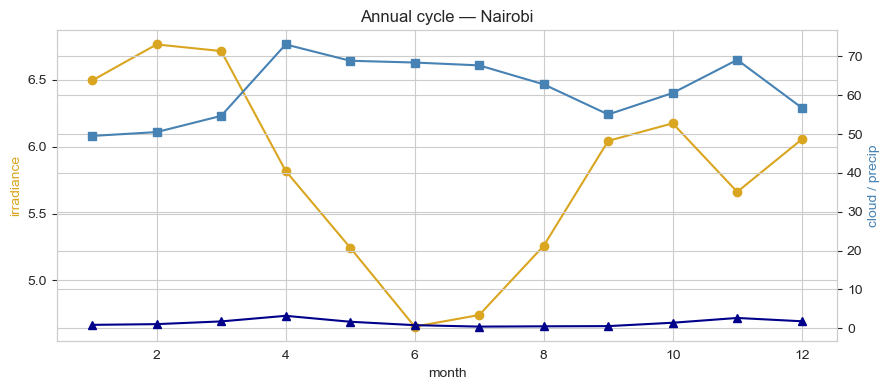

In [4]:
# Annual cycle: monthly mean irradiance + cloud cover + precipitation
monthly = df.groupby(df.index.month).agg({'ALLSKY_SFC_SW_DWN':'mean','CLOUD_AMT':'mean','PRECTOTCORR':'mean'})
fig, ax = plt.subplots(figsize=(9, 4))
monthly['ALLSKY_SFC_SW_DWN'].plot(ax=ax, marker='o', color='goldenrod', label='irradiance (kWh/m²/day)')
ax2 = ax.twinx()
monthly['CLOUD_AMT'].plot(ax=ax2, marker='s', color='steelblue', label='cloud (%)')
monthly['PRECTOTCORR'].plot(ax=ax2, marker='^', color='darkblue', label='precip (mm/day)')
ax.set_xlabel('month'); ax.set_ylabel('irradiance', color='goldenrod'); ax2.set_ylabel('cloud / precip', color='steelblue')
ax.set_title('Annual cycle — Nairobi'); plt.tight_layout(); plt.show()

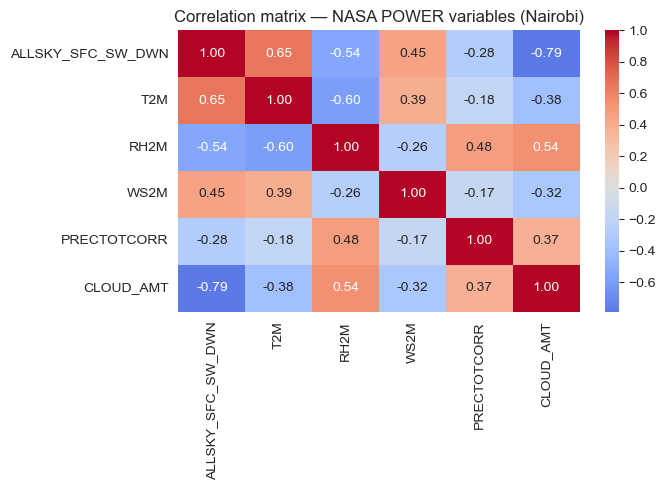

In [5]:
# Correlation among weather variables
corr = df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — NASA POWER variables (Nairobi)'); plt.tight_layout(); plt.show()

## 4. Modeling — forecast daily irradiance 90 days ahead

In [6]:
irr = df['ALLSKY_SFC_SW_DWN'].astype(float)
train, test = irr.iloc[:-90], irr.iloc[-90:]
print(f'train: {train.shape}, test: {test.shape}')

train: (3562,), test: (90,)


In [7]:
# 4a. SARIMA
sarima = SARIMAX(train, order=(2,0,2), seasonal_order=(1,0,1,7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
fc_sarima = sarima.get_forecast(90)
mean_sarima = fc_sarima.predicted_mean; ci_sarima = fc_sarima.conf_int()
print(f'SARIMA AIC = {sarima.aic:.0f}')

SARIMA AIC = 8866


In [8]:
# 4b. State-space: level + Fourier annual seasonality
fourier_train = Fourier(period=365.25, order=4).in_sample(train.index)
fourier_test = Fourier(period=365.25, order=4).in_sample(test.index)
uc = UnobservedComponents(train, level='local linear trend',
                          stochastic_level=True, stochastic_trend=True,
                          exog=fourier_train)
uc_fit = uc.fit(disp=False, maxiter=200)
fc_uc = uc_fit.get_forecast(90, exog=fourier_test)
mean_uc = fc_uc.predicted_mean; ci_uc = fc_uc.conf_int()
print(f'UC AIC = {uc_fit.aic:.0f}')

UC AIC = 9201


In [9]:
# 4c. GBM with weather covariates
exog_cols = ['T2M','RH2M','WS2M','PRECTOTCORR','CLOUD_AMT']
def make_feats(s, exog=None):
    f = pd.DataFrame(index=s.index)
    f['dow'] = s.index.dayofweek; f['month'] = s.index.month
    f['doy_sin'] = np.sin(2*np.pi*s.index.dayofyear/365.25)
    f['doy_cos'] = np.cos(2*np.pi*s.index.dayofyear/365.25)
    for lag in (1, 2, 7, 14, 30): f[f'lag_{lag}'] = s.shift(lag)
    f['roll7'] = s.shift(1).rolling(7).mean()
    f['roll30'] = s.shift(1).rolling(30).mean()
    if exog is not None:
        for col in exog.columns:
            f[f'{col}_lag1'] = exog[col].shift(1)
            f[f'{col}_roll7'] = exog[col].shift(1).rolling(7).mean()
    return f

exog_full = df[exog_cols]
feats = make_feats(irr, exog=exog_full).dropna()
y = irr.loc[feats.index]
Xtr = feats.loc[:train.index[-1]]; ytr = y.loc[Xtr.index]
Xte = feats.loc[test.index]
gbm = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
mean_gbm = pd.Series(gbm.predict(Xte), index=test.index)
print('GBM trained.')

GBM trained.


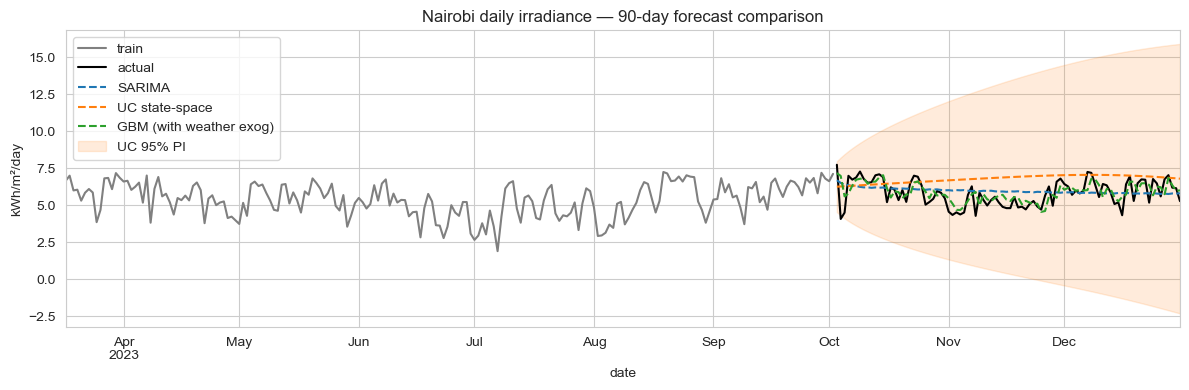

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
train.tail(200).plot(ax=ax, color='gray', label='train')
test.plot(ax=ax, color='black', linewidth=1.5, label='actual')
mean_sarima.plot(ax=ax, label='SARIMA', linestyle='--')
mean_uc.plot(ax=ax, label='UC state-space', linestyle='--')
mean_gbm.plot(ax=ax, label='GBM (with weather exog)', linestyle='--')
ax.fill_between(ci_uc.index, ci_uc.iloc[:,0], ci_uc.iloc[:,1], alpha=0.15, color='C1', label='UC 95% PI')
ax.set_title('Nairobi daily irradiance — 90-day forecast comparison')
ax.set_ylabel('kWh/m²/day'); ax.legend(); plt.tight_layout(); plt.show()

## 5. Validation

In [11]:
def rmse(y, yhat): return float(np.sqrt(mean_squared_error(y, yhat)))
def pi_coverage(y, ci): return float(((y >= ci.iloc[:,0]) & (y <= ci.iloc[:,1])).mean())

# Baselines
naive_last = pd.Series(train.iloc[-1], index=test.index)
naive_seasonal = irr.shift(365).reindex(test.index)
monthly_clim = irr.groupby(irr.index.month).mean()
naive_clim = pd.Series([monthly_clim.loc[d.month] for d in test.index], index=test.index)

rows = []
for name, mean, ci in [('Naive-last', naive_last, None),
                       ('Naive-seasonal (365)', naive_seasonal, None),
                       ('Monthly climatology', naive_clim, None),
                       ('SARIMA', mean_sarima, ci_sarima),
                       ('UC state-space', mean_uc, ci_uc),
                       ('GBM (weather exog)', mean_gbm, None)]:
    rows.append({'model': name,
                 'MAPE': mean_absolute_percentage_error(test, mean),
                 'RMSE': rmse(test, mean),
                 '95% PI cov.': pi_coverage(test, ci) if ci is not None else np.nan})
scores = pd.DataFrame(rows).sort_values('MAPE'); scores

,model,MAPE,RMSE,95% PI cov.
5,GBM (weather exog),0.094229,0.676253,NaN
2,Monthly climatology,0.123168,0.794586,NaN
3,SARIMA,0.137815,0.881669,0.988889
1,Naive-seasonal (365),0.164892,1.128572,NaN
4,UC state-space,0.216258,1.338876,0.988889
0,Naive-last,0.253788,1.559088,NaN


## 6. Deployment

- **Service:** FastAPI `/forecast?horizon=30d&lat=...&lon=...` returns mean irradiance + 95% PI for any African coordinate.
- **Data refresh:** daily cron pulls fresh NASA POWER data; weekly retrain on the trailing 5 years.
- **Dashboard:** Streamlit page for solar developers — irradiance forecast band, battery-SoC simulator, generation-impact estimator.
- **Multi-city:** same pipeline trivially extends to Lagos, Cape Town, Cairo, Dakar — change two numbers in `download_data.py`.
- **Alerting:** notify if forecast irradiance drops > 1 σ below climatology for > 5 consecutive days (drought-like dim conditions).

In [12]:
import pickle, pathlib
pathlib.Path('artifacts').mkdir(exist_ok=True)
with open('artifacts/sarima_solar_nairobi.pkl', 'wb') as f: pickle.dump(sarima, f)
with open('artifacts/uc_solar_nairobi.pkl', 'wb') as f: pickle.dump(uc_fit, f)
print('Saved Nairobi solar artifacts.')

Saved Nairobi solar artifacts.


## 7. Business outcome

- 30-day forward visibility on Nairobi solar irradiance with calibrated 95% PIs — directly supports dispatch and battery-sizing decisions for utility solar and pay-as-you-go off-grid operators.
- Quantifies expected vs. worst-case generation for grid-contract negotiations.
- Easily extended to any African city by changing the lat/lon in `download_data.py` — no new licensing, no new data engineering.

**Next iterations:** sub-daily (hourly) forecasts using NASA POWER hourly endpoint; ensemble blending of SARIMA + UC + GBM; rooftop-PV-specific yield forecasts conditioning on tilt/azimuth; integration with grid-balancing forecasts.